<a href="https://colab.research.google.com/github/bkhn85dn/xac_dinh_va_phan_xu_diem_sai/blob/main/multiview_MDV_from_2json.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

tải MDVPose.zip lên môi trường, và phải sử dụng GPU để chạy

In [ ]:
!unzip "/content/MDVPose.zip"

Archive:  /content/MDVPose.zip
   creating: MDVPose/
   creating: MDVPose/.git/
  inflating: MDVPose/.git/config     
  inflating: MDVPose/.git/description  
   creating: MDVPose/.git/gk/
  inflating: MDVPose/.git/gk/config  
  inflating: MDVPose/.git/HEAD       
   creating: MDVPose/.git/hooks/
  inflating: MDVPose/.git/hooks/applypatch-msg.sample  
  inflating: MDVPose/.git/hooks/commit-msg.sample  
  inflating: MDVPose/.git/hooks/fsmonitor-watchman.sample  
  inflating: MDVPose/.git/hooks/post-update.sample  
  inflating: MDVPose/.git/hooks/pre-applypatch.sample  
  inflating: MDVPose/.git/hooks/pre-commit.sample  
  inflating: MDVPose/.git/hooks/pre-merge-commit.sample  
  inflating: MDVPose/.git/hooks/pre-push.sample  
  inflating: MDVPose/.git/hooks/pre-rebase.sample  
  inflating: MDVPose/.git/hooks/pre-receive.sample  
  inflating: MDVPose/.git/hooks/prepare-commit-msg.sample  
  inflating: MDVPose/.git/hooks/push-to-checkout.sample  
  inflating: MDVPose/.git/hooks/sendemail-v

In [ ]:
%cd MDVPose

/content/MDVPose


In [ ]:
! pip install -r requirements.txt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.6/50.6 kB 3.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.5/87.5 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 43.8 MB/s eta 0:00:00
  Created wheel for chumpy: filename=chumpy-0.70-py3-none-any.whl size=58263 sha256=3713f9b551205afaebd9b6360356978a2b8d35424a33293b2b0dc19197313b03
  Stored in directory: /root/.cache/pip/wheels/ae/b7/0e/6f56330e9077b8a6aad99bdb76981b07a7e8b3f056def662a6
Successfully built chumpy


In [ ]:
# nhớ đặt tên file json la 'alphapose-results.json' va 'alphapose-results_2.json', hien tai trong file MDVPose tải lên đã có sẵn
# nhưng nếu thay đổi file json thì xóa file cũ đi, và tải lên đây với tên như trên
!python json_to_pkl.py

In [ ]:
!mkdir -p data/motion3d/MB3D_f243s81/H36M/train
!mkdir -p data/motion3d/MB3D_f243s81/H36M/test

In [ ]:
%cp data/motion3d/MB3D_f243s81/test.pkl data/motion3d/test.pkl

In [ ]:
import os
import sys
import pickle
import numpy as np
from tqdm import tqdm

# Thêm thư mục hiện tại vào đường dẫn hệ thống để import thư viện lib/
sys.path.insert(0, os.getcwd())
from lib.data.datareader_multiview_h36m import DataReaderH36M_MV

def save_clips(subset_name, root_path, data, labels, filenames):
    save_path = os.path.join(root_path, subset_name)
    os.makedirs(save_path, exist_ok=True)
    index = np.arange(1, 244) # 243 frames theo đúng config

    for i in tqdm(range(len(data)), desc=f"Lưu {subset_name} clips"):
        data_input = data[i]
        data_label = labels[i]
        data_dict = {
            "index": index,
            "data_input": data_input,
            "data_label": data_label
        }
        with open(os.path.join(save_path, filenames[i]), "wb") as f:
            pickle.dump(data_dict, f)

if __name__ == "__main__":
    print("1. Khởi tạo DataReader để đọc file test.pkl...")
    datareader = DataReaderH36M_MV(
        n_frames=243,
        sample_stride=1,
        data_stride_train=81,
        data_stride_test=243,
        dt_file='test.pkl',
        dt_root='data/motion3d'
    )

    # --- TRICK GIẢI QUYẾT LỖI KEYERROR TẠI ĐÂY ---
    # Ép tập Train trở thành bản sao y hệt của tập Test để đánh lừa Dataloader
    print("-> Đang nhân bản tập Test sang tập Train để vượt qua bước check của Dataloader...")
    datareader.dt_dataset['train'] = datareader.dt_dataset['test']
    # ----------------------------------------------

    print("2. Đang tiến hành cắt dữ liệu thành các clip 243 frames...")
    train_data, test_data, train_labels, test_labels, filename_train, filename_test = datareader.get_sliced_data()

    # Chuẩn hóa gốc tọa độ theo frame đầu tiên (giữ đúng logic của tác giả)
    if len(test_data) > 0:
        first_row_first_two = test_data[:, :, 0, :2]
        test_data[:, :, :, :2] -= first_row_first_two[:, :, np.newaxis, :]
        first_row = test_labels[:, :, 0]
        test_labels -= first_row[:, :, np.newaxis]

    if len(train_data) > 0:
        first_row_first_two = train_data[:, :, 0, :2]
        train_data[:, :, :, :2] -= first_row_first_two[:, :, np.newaxis, :]
        first_row = train_labels[:, :, 0]
        train_labels -= first_row[:, :, np.newaxis]

    # Đích đến: thư mục mà Dataloader đang cần
    root_path = "data/motion3d/MB3D_f243s81/H36M"
    os.makedirs(root_path, exist_ok=True)

    print(f" -> Số lượng clip train tạo ra: {len(train_data)}")
    print(f" -> Số lượng clip test tạo ra: {len(test_data)}")

    print("3. Đang ghi file ra ổ cứng...")
    if len(train_data) > 0:
        save_clips("train", root_path, train_data, train_labels, filename_train)
    if len(test_data) > 0:
        save_clips("test", root_path, test_data, test_labels, filename_test)

    print("\n[THÀNH CÔNG] Dữ liệu đã sẵn sàng. Bạn hãy chạy lại lệnh train_mv_finetune.py!")

1. Khởi tạo DataReader để đọc file test.pkl...
-> Đang nhân bản tập Test sang tập Train để vượt qua bước check của Dataloader...
2. Đang tiến hành cắt dữ liệu thành các clip 243 frames...
 -> Số lượng clip train tạo ra: 6
 -> Số lượng clip test tạo ra: 2
3. Đang ghi file ra ổ cứng...


Lưu test clips: 100%|██████████| 2/2 [00:00<00:00, 3743.24it/s]


[THÀNH CÔNG] Dữ liệu đã sẵn sàng. Bạn hãy chạy lại lệnh train_mv_finetune.py!


In [ ]:
import pickle

pkl_path = 'data/motion3d/test.pkl'

# Đọc file gốc lên
with open(pkl_path, 'rb') as f:
    data = pickle.load(f)

# Sửa lỗi vĩnh viễn: Ép train giống hệt test
data['train'] = data['test']

# Lưu ngược lại vào ổ cứng
with open(pkl_path, 'wb') as f:
    pickle.dump(data, f)

print("Đã sửa xong file test.pkl vĩnh viễn!")

Đã vá xong file test.pkl vĩnh viễn!


In [ ]:
!python train_mv_finetune.py \
    --config configs/multi_view/MB_ft_mv_h36m.yaml \
    --evaluate checkpoint/multi_view/h36m/best_epoch.bin

{'train_2d': False, 'no_eval': False, 'finetune': True, 'partial_train': None, 'epochs': 60, 'checkpoint_frequency': 30, 'batch_size': 2, 'dropout': 0.0, 'learning_rate': 0.0001, 'weight_decay': 0.01, 'lr_decay': 0.95, 'mask_view': False, 'probability': 0.1, 'maxlen': 243, 'dim_feat': 512, 'mlp_ratio': 2, 'depth': 5, 'dim_rep': 512, 'num_heads': 8, 'att_fuse': True, 'is_freeze': False, 'data_root': 'data/motion3d/MB3D_f243s81/', 'subset_list': ['H36M'], 'dt_file': 'test.pkl', 'clip_len': 243, 'data_stride': 81, 'rootrel': True, 'sample_stride': 1, 'num_joints': 17, 'no_conf': False, 'gt_2d': False, 'lambda_3d_velocity': 20.0, 'lambda_scale': 0.5, 'lambda_lv': 0, 'lambda_lg': 0, 'lambda_a': 0, 'lambda_av': 0, 'lambda_mv': 0.01, 'synthetic': False, 'flip': True, 'mask_ratio': 0.0, 'mask_T_ratio': 0.0, 'noise': False, 'name': 'MB_ft_mv_h36m'}
Loading dataset...
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 12 worker pr

Đang áp dụng bộ lọc Savitzky-Golay (Window: 15, Poly: 3)...
[THÀNH CÔNG] Dữ liệu đã khử nhiễu được lưu tại: fused_3d_pose_smoothed.npy


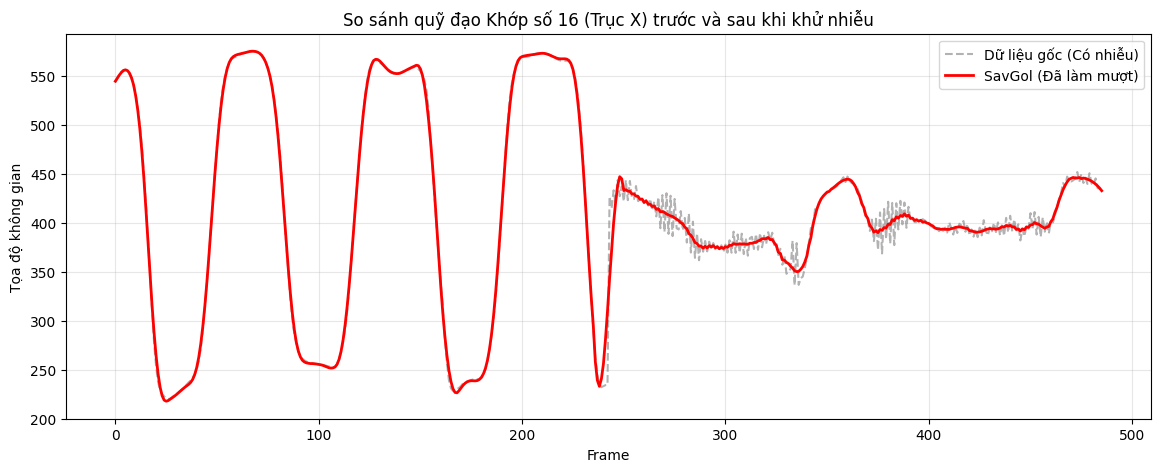

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

# 1. Tải dữ liệu 3D gốc
data = np.load('checkpoint/fused_3d_pose.npy')
poses = data.reshape(-1, 17, 3) # Chuyển về dạng (Tổng số frame, 17, 3)
num_frames = poses.shape[0]

# 2. Cấu hình tham số bộ lọc Savitzky-Golay
# window_length: Cửa sổ trượt (BẮT BUỘC LÀ SỐ LẺ).
# -> Tăng lên (15, 21, 31) nếu video quá rung lắc. Giảm xuống (7, 9, 11) nếu chuyển động bị "lờ đờ".
window_length = 15

# polyorder: Bậc đa thức.
# -> Bậc 2 hoặc 3 là chuẩn nhất cho chuyển động của con người (bảo toàn gia tốc tốt).
polyorder = 3

print(f"Đang áp dụng bộ lọc Savitzky-Golay (Window: {window_length}, Poly: {polyorder})...")

# 3. Áp dụng nội suy dọc theo trục thời gian (axis=0)
poses_smoothed = savgol_filter(poses, window_length=window_length, polyorder=polyorder, axis=0)

# 4. Lưu lại dữ liệu "Sạch"
save_path = 'fused_3d_pose_smoothed.npy'
np.save(save_path, poses_smoothed)
print(f"[THÀNH CÔNG] Dữ liệu đã khử nhiễu được lưu tại: {save_path}")

# 5. TRỰC QUAN HÓA: So sánh quỹ đạo của Cổ tay phải (Khớp số 16) trên trục X
joint_idx = 16 # Bạn có thể đổi số này (0-16) để xem các khớp khác
axis_idx = 0   # 0: X, 1: Y, 2: Z

plt.figure(figsize=(14, 5))
plt.plot(poses[:, joint_idx, axis_idx], label='Dữ liệu gốc (Có nhiễu)', color='gray', alpha=0.6, linestyle='--')
plt.plot(poses_smoothed[:, joint_idx, axis_idx], label='SavGol (Đã làm mượt)', color='red', linewidth=2)

plt.title(f'So sánh quỹ đạo Khớp số {joint_idx} (Trục X) trước và sau khi khử nhiễu')
plt.xlabel('Frame')
plt.ylabel('Tọa độ không gian')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# 1. Tải và gộp dữ liệu
# Đưa từ (2, 243, 17, 3) thành (486, 17, 3) để thành 1 video liền mạch
data = np.load('fused_3d_pose_smoothed.npy')
poses = data.reshape(-1, 17, 3)
num_frames = poses.shape[0]

# 2. Định nghĩa khung xương (Skeleton) theo chuẩn 17 joints của Human3.6M
skeleton = [
    (0, 1), (1, 2), (2, 3),       # Chân phải
    (0, 4), (4, 5), (5, 6),       # Chân trái
    (0, 7), (7, 8), (8, 9), (9, 10), # Cột sống và Đầu
    (8, 11), (11, 12), (12, 13),  # Tay trái
    (8, 14), (14, 15), (15, 16)   # Tay phải
]

# 3. Xử lý hệ tọa độ (Để hình người đứng thẳng trong Matplotlib)
# Thường thì Tọa độ Y của ảnh gốc là chiều dọc (hướng xuống), Z là chiều sâu.
# Ta sẽ map lại: Trục ngang Matplotlib = X, Trục sâu = Z, Trục cao = -Y
x_coords = poses[:, :, 0]
y_coords = poses[:, :, 2]
z_coords = -poses[:, :, 1]

# Tính toán Box cố định để camera không bị giật lùi theo từng frame
x_min, x_max = np.min(x_coords), np.max(x_coords)
y_min, y_max = np.min(y_coords), np.max(y_coords)
z_min, z_max = np.min(z_coords), np.max(z_coords)

max_range = np.array([x_max-x_min, y_max-y_min, z_max-z_min]).max() / 2.0
mid_x = (x_max+x_min) * 0.5
mid_y = (y_max+y_min) * 0.5
mid_z = (z_max+z_min) * 0.5

# 4. Khởi tạo biểu đồ
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

def update(frame):
    ax.clear()

    # Cố định giới hạn trục
    ax.set_xlim(mid_x - max_range, mid_x + max_range)
    ax.set_ylim(mid_y - max_range, mid_y + max_range)
    ax.set_zlim(mid_z - max_range, mid_z + max_range)

    ax.set_xlabel('Trục X (Ngang)')
    ax.set_ylabel('Trục Z (Sâu)')
    ax.set_zlabel('Trục Y (Cao)')
    ax.set_title(f"3D Pose Fused - Frame {frame}")

    # Lấy tọa độ frame hiện tại
    xs = x_coords[frame]
    ys = y_coords[frame]
    zs = z_coords[frame]

    # Vẽ các khớp xương (Joints)
    ax.scatter(xs, ys, zs, c='red', s=20)

    # Vẽ các đoạn nối (Bones)
    for bone in skeleton:
        start, end = bone
        ax.plot([xs[start], xs[end]],
                [ys[start], ys[end]],
                [zs[start], zs[end]], c='blue', linewidth=2)

    # Chỉnh góc nhìn camera 3D (bạn có thể thay đổi để xem từ trên/dưới/ngang)
    ax.view_init(elev=10, azim=45)

print(f"Đang render {num_frames} frames... Quá trình này sẽ mất khoảng 1-2 phút.")

# 5. Render và hiển thị Video
anim = FuncAnimation(fig, update, frames=num_frames, interval=1000/30) # Render ở 30 FPS
plt.close() # Đóng plot tĩnh

HTML(anim.to_html5_video())

Đang render 486 frames... Quá trình này sẽ mất khoảng 1-2 phút.


In [ ]:
from google.colab import files

print("Đang đóng gói video thành file MP4 (sẽ mất khoảng vài chục giây)...")
# Lưu animation thành file MP4 trên ổ cứng của máy chủ Colab
anim.save('fused_3d_pose.mp4', writer='ffmpeg', fps=30)
print("Đóng gói hoàn tất! Đang tiến hành tải về máy tính của bạn...")

# Lệnh này sẽ kích hoạt trình duyệt của bạn tự động tải file xuống
files.download('fused_3d_pose.mp4')

Đang đóng gói video thành file MP4 (sẽ mất khoảng vài chục giây)...
Đóng gói hoàn tất! Đang tiến hành tải về máy tính của bạn...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>